In [62]:
# Leitura dos dados e importações
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


df = pd.read_csv('bank_marketing_completo.csv')

### Descrição das variáveis da base

| Variável                      | Descrição                                                                            | Valores / exemplo                                                                                                                                     |
| ----------------------------- | ------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
| `idade`                       | Idade do cliente                                                                     | 41                                                                                                                                                    |
| `profissao`                   | Ocupação do cliente                                                                  | administrativo, operario, tecnico, servicos, gerencia, aposentado, empreendedor, autonomo, empregado_domestico, desempregado, estudante, desconhecido |
| `estado_civil`                | Estado civil do cliente                                                              | casado, solteiro, divorciado, desconhecido                                                                                                            |
| `escolaridade`                | Escolaridade do cliente                                                              | fundamental_4anos, fundamental_6anos, fundamental_9anos, ensino_medio, curso_profissionalizante, superior, analfabeto, desconhecido                   |
| `inadimplente`                | Indica se o cliente possui crédito em atraso                                         | nao, sim, desconhecido                                                                                                                                |
| `financiamento_imobiliario`   | Indica se o cliente possui financiamento imobiliário                                 | nao, sim, desconhecido                                                                                                                                |
| `emprestimo_pessoal`          | Indica se o cliente possui empréstimo pessoal                                        | nao, sim, desconhecido                                                                                                                                |
| `meio_contato`                | Meio utilizado no último contato                                                     | celular, telefone_fixo                                                                                                                                |
| `mes`                         | Mês do último contato                                                                | mar, abr, mai, jun, jul, ago, set, out, nov, dez                                                                                                      |
| `dia_semana`                  | Dia da semana do último contato                                                      | seg, ter, qua, qui, sex                                                                                                                               |
| `duracao_ligacao_seg`         | Duração do último contato, em segundos                                               | 261                                                                                                                                                   |
| `contatos_campanha_atual`     | Número de contatos com o cliente na campanha atual, incluindo o último               | 1                                                                                                                                                     |
| `dias_desde_ultimo_contato`   | Dias desde o último contato em campanha anterior; 999 indica que nunca foi contatado | 999                                                                                                                                                   |
| `contatos_anteriores`         | Número de contatos realizados em campanhas anteriores                                | 0                                                                                                                                                     |
| `resultado_campanha_anterior` | Resultado obtido na campanha anterior                                                | fracasso, sucesso, inexistente                                                                                                                        |
| `taxa_variacao_emprego`       | Indicador macroeconômico: variação trimestral do emprego                             | 1.1                                                                                                                                                   |
| `indice_precos_consumidor`    | Indicador macroeconômico: índice mensal de preços ao consumidor                      | 93.994                                                                                                                                                |
| `indice_confianca_consumidor` | Indicador macroeconômico: índice de confiança do consumidor                          | -36.4                                                                                                                                                 |
| `euribor_3m`                  | Indicador macroeconômico: taxa Euribor de 3 meses                                    | 4.857                                                                                                                                                 |
|                               |                                                                                      |                                                                                                                                                       |

A base de dados contém 41.188 registros e 21 variáveis. As variáveis representam características dos clientes, informações relacionadas aos contatos realizados e indicadores do contexto econômico no momento da campanha.

## 4.1 Análise Descritiva

Apresentar as dimensões da base, os tipos de dados, a distribuição da variável-alvo e ao menos três
visualizações que relacionem atributos à adesão. Descrever a qualidade da base e registrar toda característica dos dados que, na avaliação da dupla, exija tratamento antes da modelagem ou influencie a forma de avaliar os modelos.

Variável-alvo --> 'Aderiu'

In [63]:
# Visão geral da base
print('Visão geral da base:')
df.head()

Visão geral da base:


,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,...,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
0,56,empregado_domestico,casado,fundamental_4anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
1,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
2,37,servicos,casado,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
3,40,administrativo,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
4,56,servicos,casado,ensino_medio,nao,nao,sim,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao


In [64]:
# Número de linhas e colunas
linhas, colunas = df.shape
print(f'Linhas totais da base: {linhas} | Colunas totais da base {colunas}\n')

# Tipos de dados da base:
print('Tipos de dados presentes na base:')
print(df.dtypes)

Linhas totais da base: 41188 | Colunas totais da base 21

Tipos de dados presentes na base:
idade                            int64
profissao                          str
estado_civil                       str
escolaridade                       str
inadimplente                       str
financiamento_imobiliario          str
emprestimo_pessoal                 str
meio_contato                       str
mes                                str
dia_semana                         str
duracao_ligacao_seg              int64
contatos_campanha_atual          int64
dias_desde_ultimo_contato        int64
contatos_anteriores              int64
resultado_campanha_anterior        str
taxa_variacao_emprego          float64
indice_precos_consumidor       float64
indice_confianca_consumidor    float64
euribor_3m                     float64
numero_empregados              float64
aderiu                             str
dtype: object


In [65]:
# Valores ausentes:
print('Total de valores nulos em cada coluna:')
print(f'{df.isna().sum()}')
print()

# Valores duplicados
print(f'Total de duplicatas na base: {df.duplicated().sum()}\n')

Total de valores nulos em cada coluna:
idade                          0
profissao                      0
estado_civil                   0
escolaridade                   0
inadimplente                   0
financiamento_imobiliario      0
emprestimo_pessoal             0
meio_contato                   0
mes                            0
dia_semana                     0
duracao_ligacao_seg            0
contatos_campanha_atual        0
dias_desde_ultimo_contato      0
contatos_anteriores            0
resultado_campanha_anterior    0
taxa_variacao_emprego          0
indice_precos_consumidor       0
indice_confianca_consumidor    0
euribor_3m                     0
numero_empregados              0
aderiu                         0
dtype: int64

Total de duplicatas na base: 12



In [66]:
# Distribuição da variável alvo 'aderiu'

# Conta quantas vezes cada valor aparece na base
print(df['aderiu'].value_counts())
print()

# Guardar quantidade de sim e não para aderiu
sim = df[['aderiu']].value_counts()['sim'] # Dentro da coluna aderiu, conte quantas vezes aparece sim
nao = df[['aderiu']].value_counts()['nao'] # O mesmo para não

# Proporção de sim e não
proporcao_sim = sim / (sim + nao)
proporcao_nao = nao / (nao + sim)

print('Análise da variável-alvo:')
print(f'Quantidade de sim: {sim}  | Proporção de sim {proporcao_sim * 100:.2f}% ')
print(f'Quantidade de não: {nao} | Proporção de não {proporcao_nao * 100:.2f}% ')

aderiu
nao    36548
sim     4640
Name: count, dtype: int64

Análise da variável-alvo:
Quantidade de sim: 4640  | Proporção de sim 11.27% 
Quantidade de não: 36548 | Proporção de não 88.73% 


In [67]:
print('Descrição estatística:')
df.describe()

Descrição estatística:


,idade,duracao_ligacao_seg,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


##### Gráficos

Visualizações que relacionam atributos à adesão

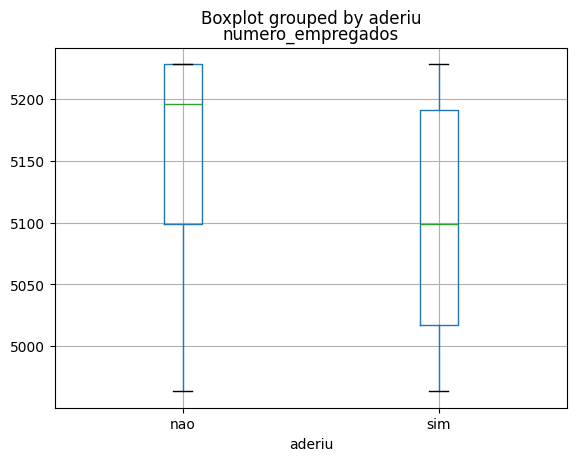

In [68]:
# Gráfico 1 - relacionando número de empregados x adesão

# Boxplot
df.boxplot(
    column='numero_empregados', # X
    by='aderiu' # Y
)
# Indicador macroeconômico: número de empregados no país (trimestral, em milhares)

# Podemos omitir as informações estranhas que aparecem
plt.show()

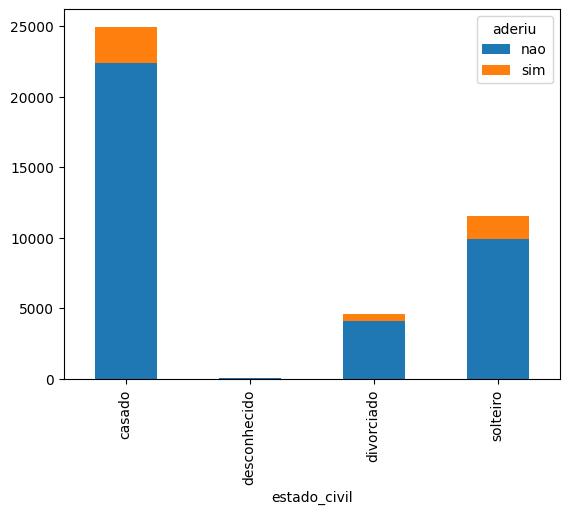

In [69]:
# Gráfico 2 - relação entre estado civil e adesão

# Contar as combinações
ec_aderiu = pd.crosstab(
    df['estado_civil'],
    df['aderiu']
)

# Barras empilhadas
ec_aderiu.plot(
    kind='bar',
    stacked=True
)

plt.show()

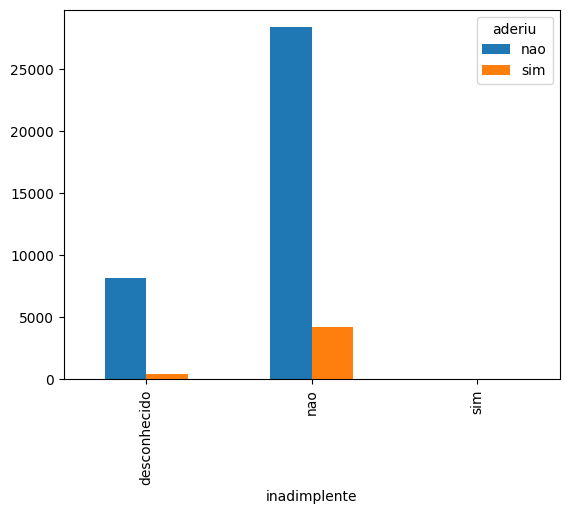

In [70]:
# Gráfico 3 - relação entre inadimplente e adesão

# Contar as combinações
inad_aderiu = pd.crosstab(
    df['inadimplente'],
    df['aderiu']
)

# Barras empilhadas
inad_aderiu.plot(
    kind='bar'
)

plt.show()

#### Descrever a qualidade da base e registrar toda característica dos dados que, na avaliação da dupla, exija tratamento antes da modelagem ou influencie a forma de avaliar os modelos.

Descrição de qualidade da base:

Não foram identificados valores nulos na base. Entretanto, foram encontrados 12 registros duplicados. Também foi identificado um desbalanceamento na variável-alvo aderiu, com aproximadamente 89% dos registros classificados como "nao" e 11% como "sim".

Além disso, a base apresenta variáveis categóricas que precisarão ser analisadas para utilização nos algoritmos. A variável "dias_desde_ultimo_contato" utiliza o valor 999 como representação de clientes que nunca haviam sido contatados anteriormente, portanto essa codificação deverá ser considerada durante a preparação dos dados.

De modo geral, a base apresenta qualiade, sem valores nulos. Porém foram identificadas algumas características que precisam ser consideradas/analisadas antes da modelagem, como registros duplicados, desbalanceamento da variável-alvo, variáveis categóricas e etc.

Características que precisam de tratamento:
1. Precisamos tratar as duplicatas que foram encontradas
2. Deve-se analisar a necessidade de normalização na base
3. Devemos transformar os campos qualitativos úteis em quantitativos para que o modelo consiga utilizá-los
4. Mesmo que a variável "dias_desde_ultimo_contato" indique 999 como "nunca foi contatado" devemos analisar a probabilidade desse valor afetar a forma de avaliação dos dados
5. Analisar a variável "indice_confianca_consumidor" e seus valores negativos, também analisar a probabilidade do valor afetar a avaliação de alguma forma

... adicionar algo caso seja preciso

##  4.2 Preparação dos dados

Realizar as transformações necessárias para que os dados possam ser utilizados pelos três algoritmos. Toda alteração na base — exclusão de registros ou colunas, imputação, recodificação, criação de atributos,escalonamento — deve ser registrada e justificada no relatório. A preparação deve ser conduzida de forma a não comprometer a validade da avaliação dos modelos.

In [71]:
# Analisar as duplicatas para decidir o que deve ser feito
df[df.duplicated(keep=False)]

,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,...,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
1265,39,operario,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,qui,...,1,999,0,inexistente,1.1,93.994,-36.4,4.855,5191.0,nao
1266,39,operario,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,qui,...,1,999,0,inexistente,1.1,93.994,-36.4,4.855,5191.0,nao
12260,36,aposentado,casado,desconhecido,nao,nao,nao,telefone_fixo,jul,qui,...,1,999,0,inexistente,1.4,93.918,-42.7,4.966,5228.1,nao
12261,36,aposentado,casado,desconhecido,nao,nao,nao,telefone_fixo,jul,qui,...,1,999,0,inexistente,1.4,93.918,-42.7,4.966,5228.1,nao
14155,27,tecnico,solteiro,curso_profissionalizante,nao,nao,nao,celular,jul,seg,...,2,999,0,inexistente,1.4,93.918,-42.7,4.962,5228.1,nao
14234,27,tecnico,solteiro,curso_profissionalizante,nao,nao,nao,celular,jul,seg,...,2,999,0,inexistente,1.4,93.918,-42.7,4.962,5228.1,nao
16819,47,tecnico,divorciado,ensino_medio,nao,sim,nao,celular,jul,qui,...,3,999,0,inexistente,1.4,93.918,-42.7,4.962,5228.1,nao
16956,47,tecnico,divorciado,ensino_medio,nao,sim,nao,celular,jul,qui,...,3,999,0,inexistente,1.4,93.918,-42.7,4.962,5228.1,nao
18464,32,tecnico,solteiro,curso_profissionalizante,nao,sim,nao,celular,jul,qui,...,1,999,0,inexistente,1.4,93.918,-42.7,4.968,5228.1,nao
18465,32,tecnico,solteiro,curso_profissionalizante,nao,sim,nao,celular,jul,qui,...,1,999,0,inexistente,1.4,93.918,-42.7,4.968,5228.1,nao


Ao analisar as 12 linhas que estão aparecendo como duplicatas, podemos notar que, os valores são IDENTICOS. Ou seja, provavelmente está se referindo a uma mesma pessoa, contendo alteração somente no id (coluna sem nome).

Também é preciso mencionar que, por padrão, o pandas verifica se todas as linhas são iguais, o que vale para o nosso caso (não precisaríamos fazer essa análise). Mesmo que, exista a possibilidade de alterar isso para que ele considere apenas certos valores idênticos (no nosso caso, está no modo padrão).

**O que iremos fazer em relação a duplicatas?**

Como os registros são exatamente os mesmos (dada a saída no terminal + padrão do comando), podemos remover as duplicatas tranquilamente.

In [72]:
# Removendo as duplicatas (sobrescrevendo sem duplicatas)
df = df.drop_duplicates()

# Analisar se ainda existe alguma duplicata
print(f'Total de duplicatas na base: {df.duplicated().sum()}')

Total de duplicatas na base: 0


Entretanto, ao analisar a tabela de duplicatas podemos notar a aparição de um campo indicado como "desconhecido" que parece se comportar do mesmo jeito que o NULL, então vamos analisá-lo.

In [73]:
# Analisando onde aparece o campo 'desconhecido' 
print((df == 'desconhecido').sum())

idade                             0
profissao                       330
estado_civil                     80
escolaridade                   1730
inadimplente                   8596
financiamento_imobiliario       990
emprestimo_pessoal              990
meio_contato                      0
mes                               0
dia_semana                        0
duracao_ligacao_seg               0
contatos_campanha_atual           0
dias_desde_ultimo_contato         0
contatos_anteriores               0
resultado_campanha_anterior       0
taxa_variacao_emprego             0
indice_precos_consumidor          0
indice_confianca_consumidor       0
euribor_3m                        0
numero_empregados                 0
aderiu                            0
dtype: int64


In [74]:
# Analisar as colunas com o campo 'desconhecido'
df_desconhecido = df[
    ['profissao',
     'estado_civil',
     'escolaridade',
     'inadimplente',
     'financiamento_imobiliario',
     'emprestimo_pessoal']
]

# Ver dados do df com dados desconhecidos
df_desconhecido.head(10)

,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal
0,empregado_domestico,casado,fundamental_4anos,nao,nao,nao
1,servicos,casado,ensino_medio,desconhecido,nao,nao
2,servicos,casado,ensino_medio,nao,sim,nao
3,administrativo,casado,fundamental_6anos,nao,nao,nao
4,servicos,casado,ensino_medio,nao,nao,sim
5,servicos,casado,fundamental_9anos,desconhecido,nao,nao
6,administrativo,casado,curso_profissionalizante,nao,nao,nao
7,operario,casado,desconhecido,desconhecido,nao,nao
8,tecnico,solteiro,curso_profissionalizante,nao,sim,nao
9,servicos,solteiro,ensino_medio,nao,sim,nao


Ao analisar as colunas, pode-se notar que, de fato, o campo "desconhecido" representa um valor que não foi informado (se comportando como um "null"). Entretanto, esses campos são qualitativos, o que dificulta a substituição dos valores que não foram informados, não parece muito correto apenas deduzir um valor qualitativo para uma coluna por constar como "desconhecido".

**O que fazer?**

Tendo em mente que, o campo "desconhecido" tem como base um valor não informado, decidiu-se que seria melhor mantê-lo do que simplesmente substituir por um valor que pode atrapalhar o modelo ou remover todas as linhas que contêm esse valor.

In [75]:
# Quantas vezes os valores aparecem na base?
df['dias_desde_ultimo_contato'].value_counts()

dias_desde_ultimo_contato
999    39661
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

O valor "999" indica que nunca houve um contato com o cliente, esse é o valor que mais aparece na base, tendo um total de 39661 aparições. É o maior valor que aparece, disparado.

Tendo em mente que serão trabalhados 3 modelos nessa base, já é possível encontrar um problema aí. Ao utilizar os dados para o k-nn pode-se ter um problema, como ele trabalha com distâncias, o valor de 999 pode afetar o modelo.

Além disso, na regressão logística, o modelo pode tratar esse valor como um valor "normal" sem compreender o significado real desse valor (nunca houve contato).

**O que fazer?**

É possível, neste caso, criar uma nova coluna que indica se o cliente foi de fato contatado ou não. Isso seria o mais correto a se fazer, pois, se simplesmente o valor fosse substituído por 0, ele poderia ter outro significado (contatado hoje), e se as linhas onde esse valor aparece fossem deletadas, perderia-se uma vasta quantidade de dados, isso não seria víavel.

Então, o melhor a se fazer é classificar em uma nova coluna se o cliente foi ou não contatado, se ele foi contatado, considera-se o valor dos dias corretamente, e se ele não foi contatado, lida-se com esse valor (999) de outro modo.

In [76]:
# Criar a nova coluna (contatato_anteriormente) na base de dados

df['contatado_anteriormente'] = np.where( # Onde o valor desta coluna for 999
    df['dias_desde_ultimo_contato'] == 999,
    'nao', # se o valor for 999, indique como nunca contatado
    'sim') # se não, já foi contatado

Agora, há duas colunas, uma ainda consta o valor 999, mas a outra indica se foi contatado ou não, agora deve-se tratar esses dois valores (sim e não) de forma diferente, como dito no md acima.

Espera-se que aconteça algo do tipo:
1. Se contatado_anteriormente = sim --> mantém o número de dias
2. Se contatado_anteriormente = nao --> não existe um número real de dias

**O que decidir?**
Vamos, primeiramente, analisar a descrição estatística dos valores reais para entender como eles se comportam

In [77]:
# Descrição estatística de "dias_desde_ultimo_contato" reais
sem_contato = df['dias_desde_ultimo_contato']

# Descrever os valores do último contato reais (onde não sejam 999)
sem_contato[sem_contato != 999].describe()

count    1515.000000
mean        6.014521
std         3.824906
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: dias_desde_ultimo_contato, dtype: float64

Ao analisar a saída dos valores, podemos notar que o valor mínimo do último contato é 0 enquanto o máximo é 27, a média e a mediana estão em torno de 6, e os quartis estão focados na faixa de 3 a 7.

Com isso, podemos notar que o valor 999 está muito distante dos valores reais apresentados e, é importante lembrando também que esse valor não representa uma quantidade de dias, mas sim a ausência de um contato anterior.

**O que fazer?**

Cosiderando que já criamos a variável "contatado_anteriormente", que classifica os clientes como "sim" ou "nao", vamos fazer o seguinte:

Vamos utilizar essa classificação para tratar a variável "dias_desde_ultimo_contato". Quando o cliente tiver sido contatado anteriormente, o valor dos dias será mantido. Quando não tiver sido contatado, o valor será multiplicado por 0, fazendo com que o 999 não seja considerado como uma quantidade real de dias.

Dessa forma, mesmo que existam valores 0 na coluna de dias, o modelo poderá diferenciar os casos por meio da coluna "contatado_anteriormente", que indicará se houve ou não um contato anterior.

In [78]:
# Tratando os valores dos "dias_desde_ultimo_contato" de acordo com o que foi decidido
df['dias_desde_ultimo_contato'] = df['dias_desde_ultimo_contato'] * np.where(
    df['contatado_anteriormente'] == 'sim',
    1, # Sim, multiplique os dias por 1
    0 # Senão, multiplique por 0
)

In [79]:
# Analisando os números de índice de confiança do consumidor
print(df['indice_confianca_consumidor'].value_counts())

indice_confianca_consumidor
-36.4    7762
-42.7    6681
-46.2    5793
-36.1    5173
-41.8    4374
-42.0    3615
-47.1    2457
-31.4     770
-40.8     715
-26.9     446
-30.1     357
-40.3     311
-37.5     303
-50.0     282
-29.8     267
-34.8     264
-38.3     233
-39.8     229
-40.0     212
-49.5     204
-33.6     177
-34.6     174
-33.0     172
-50.8     128
-40.4      67
-45.9      10
Name: count, dtype: int64


Apesar de todos os valores serem negativos, não foram encontradas evidências, até o momento, de que isso represente um erro nos dados.

Portanto, a variável será mantida como está, sendo considerada (se necessário) na análise e na modelagem.

Agora, vamos analisar a necessidade de normalização da base, será que a diferença na escala das variáveis pode atrapalhar nossos modelos?

In [80]:
# Olhar novamente a descrição estatística da tabela (já foi feito na análise descritiva)
df.describe()

,idade,duracao_ligacao_seg,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,0.221294,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,1.349065,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,0.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,0.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,0.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,27.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Pelo describe conseguimos perceber que, de certo modo, as variáveis estão em escalas diferentes, como por exemplo, duração da ligação (máx = 4918) e dias desde o último contato (máx = 27).

Também podemos ver esses valores em número de empregados (máx = 5228) e taxa de variação do emprego (máx = 1.40).

Dada a grande diferença nos valores, uma escala pode acabar tendo um peso maior do que outra, e isso pode causa problemas no modelo de k-nn, por exemplo. Dessa forma, teremos que realizar a padronização das variáveis numéricas antes da modelagem.

Vale lembrar que: vamos aplicar a padronização nas variáveis quantitativas, não iremos aplicar nas qualitativas.

In [81]:
# Separar alvo e dividir treino e teste

# Separar não aderiu (X) de aderiu (Y)
X = df.drop('aderiu', axis=1)
y = df['aderiu']

# Separação do treino e teste (lembrar de manter a mesma proporção com stratify)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [82]:
# Separa entre colunas numéricas e categóricas
num = X.select_dtypes(include=[np.number]).columns.tolist()
cat = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Montar ramo numérico
pipe_num = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escala', StandardScaler())
])

# Montar ramo categórico
pipe_cat = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')), # Preenche colunas sem valor (NaN)
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


Obs: Estamos adicionando "sparse_output=False" pois, ao iniciar a parte da modelagem do naïve bayes, vimos que seria necessário para fazer a comparação entre as duas variantes.

O sparse_output=False faz com que o OneHotEncoder retorne os dados em uma matriz normal, facilitando o uso pelo GaussianNB.

In [83]:
# Unir os dois ramos
preparacao = ColumnTransformer([ # ColumnTransformer transforma as colunas, executa os pipelines
    ('num', pipe_num, num), # aplica pipe_num nas colunas num
    ('cat', pipe_cat, cat), # aplica pipe_cat nas colunas cat
])

### Preparação concluída

Com os tratamentos realizados e a preparação dos dados estruturada, a base está pronta para ser utilizada nos modelos de classificação.

## 4.3 Modelagem

Treinar os três classificadores sobre o mesmo conjunto de treino e a mesma preparação de dados:

1. k-vizinhos mais próximos (k-NN);
2. Naive Bayes: a dupla deve escolher a variante adequada (GaussianNB, BernoulliNB ou
CategoricalNB) e justificar a escolha em função do tipo dos atributos. É permitido, e recomendado,
comparar duas variantes;
3. Regressão logística: além do desempenho, interpretar os cinco coeficientes de maior magnitude.


**Escolha de hiperparâmetros:**

A escolha de hiperparâmetros relevantes — no mínimo o valor de k no k-NN e o
parâmetro de regularização C na regressão logística — deve ser justificada por validação cruzada, e não por tentativa e erro sobre o conjunto de teste. Dado o tamanho da base, é permitido realizar essa busca sobre uma amostra estratificada do conjunto de treino, desde que o procedimento seja documentado e o modelo final seja treinado sobre o conjunto de treino completo.

### k-NN

Nesta etapa, será utilizado o modelo k-nn. A preparação dos dados definida anteriormente será aplicada junto ao modelo por meio de um pipeline. O valor de k será escolhido posteriormente por validação cruzada utilizando o conjunto de treino, como solicitado na etapa.

#### Validação Cruzada

**Para encontrar o melhor hiperparâmetro.**

In [84]:
# Essa função monta um pipeline para nós, ela devolve um pipeline
def montar(k, peso='uniform'):
    return Pipeline([
        ('preparacao', preparacao), # Utilizando a nossa preparação de dados
        ('knn', KNeighborsClassifier(n_neighbors=k, weights=peso))
    ])


Obs: Usamos a mesma preparação **("preparacao", preparacao)** nos três modelos porque o enunciado exige que eles sejam treinados com o mesmo conjunto e a mesma preparação de dados. Assim, conseguimos comparar os algoritmos de forma justa, sem que diferenças no tratamento dos dados influenciem os resultados.

In [85]:
resultado = []

validacao = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Informando que a classe positiva é aderiu = sim
metricas = {
    'recall_sim': make_scorer(
        recall_score,
        pos_label='sim'
    ),
    'precisao_sim': make_scorer(
        precision_score,
        pos_label='sim',
        zero_division=0
    ),
    'f1_sim': make_scorer(
        f1_score,
        pos_label='sim'
    )
}


# Sempre usamos ímpares
for k in [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43]:
    # A validação cruzada serve para nos mostrar o melhor valor de k | Cv é o número de dobras
    notas = cross_validate(montar(k), X_treino, y_treino, cv=validacao, scoring=metricas)
    
    resultado.append({
        'k': k,
        'recall_medio': notas['test_recall_sim'].mean(),
        'recall_desvio': notas['test_recall_sim'].std(),
        'precisao_media': notas['test_precisao_sim'].mean(),
        'f1_medio': notas['test_f1_sim'].mean(),
        'f1_desvio': notas['test_f1_sim'].std()
    })
    
resultado_knn = pd.DataFrame(resultado)
resultado_knn.sort_values('recall_medio', ascending=False)

melhor_k = max(
    resultado,
    key=lambda item: item['f1_medio']
)['k']

print(melhor_k)

7


Neste caso, é importante ressaltar que para o caso do banco, o pior erro que o modelo pode cometer seriam os falsos negativos, já que é muito pior o banco classificar erroneamente um cliente como não aderente e ele ser um aderente, seria um cliente perdido para o banco. Logo, o melhor k deve ser encontrado através de validação cruzada utilizando recall como principal métrica.

Após a validação cruzada com recall como principal métrica percebeu-se que, embora k=1 tenha apresentado o maior recall da classe positiva, sua precisão e seu F1 foram inferiores, indicando uma quantidade elevada de falsos positivos. O valor k=7 foi escolhido por apresentar o maior recall médio entre as configurações com precisão superior a 60%, além do maior F1 médio e de baixa variação do recall entre as partições. Essa escolha preserva a prioridade de identificar clientes com potencial de adesão, mas evita um volume excessivo de contatos sem conversão.

In [86]:
# Criar o modelo final do knn usando o melhor k encontrado na validação cruzada utilizando a função
# que já monta um pipe para nós (apenas passando o modelo para criar)
modelo_knn = montar(melhor_k)

# Treinar o knn
modelo_knn.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacao', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['nao','sim']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['idade','profissao','estado_civil',...,'euribor_3m','numero_empregados', 'contatado_anteriormente']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

### Naïve Bayes

Como em sala só fizemos a variante **GaussianNB** decidi pesquisar sobre o que as demais variantes fazem antes de decidir duas entre as três para podemos seguir para a comparação das duas (também fiz uma pesquisa da gaussianNB).

**Gaussiana:**
1. Calcula probabilidades: Estima a chance de uma amostra pertencer a uma determinada classe (por exemplo, "spam" ou "não spam"). 
2. Assume distribuição normal (Gaussiana): Assume que os dados numéricos de cada classe seguem uma curva em formato de sino (distribuição normal).
3. Faz previsões rápidas: É ideal para bases de dados grandes porque calcula os parâmetros (média e variância) de cada atributo de forma independente.
4. Ele é pensado principalmente para variáveis numéricas contínuas

Parece ser uma escolha interessante porque temos muitas variáveis numéricas.

**BernoulliNB**
1. Distribuição de Bernoulli: Ele calcula probabilidades assumindo que cada dado de entrada é uma escolha binária (sim ou não, presente ou ausente).
2. Foco em Presença: Ele olha apenas se uma característica está presente (1) ou ausente (0), ignorando quantas vezes ela se repete.
3. É voltado para variáveis binárias, ou seja, aquelas que basicamente representam: 0 ou 1, spam ou não spam.

No nosso caso, ele possui uma relação com a preparação dos dados, pois as variáveis categóricas foram transformadas pelo OneHotEncoder em várias colunas binárias, com valores 0 e 1. Dessa forma, mesmo que essas variáveis originalmente possuam mais de duas categorias, elas passam a ser representadas por características binárias.

**CategoricalNB**
1. Calcula probabilidades: Ele usa o Teorema de Bayes para estimar a probabilidade de uma amostra pertencer a uma determinada classe com base em suas características categóricas
2. Conta frequências: Ele calcula a contagem de frequência de cada categoria para classe do conjunto de dados para gerar as probabilidades condicionais.
3. É pensado para variáveis categóricas, em que cada valor representa uma categoria, como: estado_civil =
casado, solteiro, divorciado.
4. Trabalha com essas categorias como categorias discreta

Parece ser uma escolha interessante inicialmente, pois nossa base possui muitos atributos categóricos, como: "escolaridade", "estado_civil" e "profissao". No entanto, como essas variáveis foram transformadas pelo OneHotEncoder em várias colunas binárias, acho que essa variante não funcionará tão bem para o nosso caso, justamente pela transformação feita pelo OneHotEncoder (se as variáveis estivessem "normais", ele trabalharia muito bem)

A base apresenta atributos numéricos contínuos e atributos categóricos transformados em variáveis binárias pelo OneHotEncoder. Por isso, nenhuma variante do Naive Bayes se ajusta perfeitamente a todos os atributos. O GaussianNB preserva a informação das variáveis numéricas contínuas, embora aplique a hipótese gaussiana também às colunas binárias.

De acordo com a pesquisa realizada, nossas melhores opções são: **GaussianNB** e **BernoulliNB**, elas são as que mais possuem relação com a nossa base e, também, parecem estar "a par" com os dados que temos nela atualmente.

#### Validação cruzada

**Para comparar o desempenho das duas variantes e decidir qual utilizar.**

Comparando as duas variantes:

In [87]:
# Criar modelo gaussian
modelo_gaussian = Pipeline([
    ('preparacao', preparacao),
    ('modelo', GaussianNB())
])

# Criar modelo bernoulli
modelo_bernoulli = Pipeline([
    ('preparacao', preparacao),
    ('modelo', BernoulliNB())
])

In [88]:
modelos_nb = {
    'GaussianNB': modelo_gaussian,
    'BernoulliNB': modelo_bernoulli
}

resultado_nb = []

for nome, modelo in modelos_nb.items():
    notas = cross_validate(
        modelo,
        X_treino,
        y_treino,
        cv=validacao,
        scoring=metricas
    )

    resultado_nb.append({
        'modelo': nome,
        'recall_medio': notas['test_recall_sim'].mean(),
        'recall_desvio': notas['test_recall_sim'].std(),
        'precisao_media': notas['test_precisao_sim'].mean(),
        'f1_medio': notas['test_f1_sim'].mean(),
        'f1_desvio': notas['test_f1_sim'].std()
    })

resultado_nb = pd.DataFrame(resultado_nb)
print(resultado_nb)

        modelo  recall_medio  recall_desvio  precisao_media  f1_medio  \
0   GaussianNB      0.564824       0.010316        0.377752  0.452563   
1  BernoulliNB      0.586690       0.009421        0.353067  0.440790   

   f1_desvio  
0   0.015291  
1   0.011460  


In [89]:
indice_melhor = resultado_nb['f1_medio'].idxmax()
melhor_resultado_nb = resultado_nb.loc[indice_melhor]

melhor_variante_nb = melhor_resultado_nb['modelo']

print(f'Melhor variante: {melhor_variante_nb}')
print(melhor_resultado_nb)

Melhor variante: GaussianNB
modelo            GaussianNB
recall_medio        0.564824
recall_desvio       0.010316
precisao_media      0.377752
f1_medio            0.452563
f1_desvio           0.015291
Name: 0, dtype: object


O GaussianNB foi selecionado por apresentar o maior F1 médio da classe sim na validação cruzada. Apesar de parte dos atributos ser binária após o one-hot, essa variante preserva a magnitude das variáveis numéricas contínuas, diferentemente do BernoulliNB, que as reduz a valores binários. O recall e a precisão também foram analisados para verificar o equilíbrio entre oportunidades perdidas e contatos sem conversão.

In [90]:
# Treinar o GaussianNB
modelo_nb = modelos_nb[melhor_variante_nb]
modelo_nb.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacao', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U3](2,)","['nao','sim']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['idade','profissao','estado_civil',...,'euribor_3m','numero_empregados', 'contatado_anteriormente']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

### Regressão Logística

Validação cruzada

**Para pegar parâmetro de regularização C**

In [91]:
def montar_rl(c):
    return Pipeline([
        ('preparacao', preparacao), # Utilizando a nossa preparação de dados
        ('RL', LogisticRegression(C=c, max_iter=1000)) # Use o melhor c | iteração máxima 1000
    ])

In [92]:
resultado2 = []

# Para C, utilizar valores em potência de 10
for c in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]:
    # A validação cruzada serve para nos mostrar o melhor valor de c | Cv é o número de dobras
    notas = cross_validate(montar_rl(c), X_treino, y_treino, cv=validacao, scoring=metricas)
    
    # A chave c recebe como valor a nota média, o melhor c é aquele com a maior média
    resultado2.append({
        'C': c,
        'recall_medio': notas['test_recall_sim'].mean(),
        'recall_desvio': notas['test_recall_sim'].std(),
        'precisao_media': notas['test_precisao_sim'].mean(),
        'f1_medio': notas['test_f1_sim'].mean(),
        'f1_desvio': notas['test_f1_sim'].std()
    })

resultado_rl = pd.DataFrame(resultado2)
print(resultado_rl)

indice_melhor = resultado_rl['f1_medio'].idxmax()
melhor_resultado_rl = resultado_rl.loc[indice_melhor]

melhor_c = melhor_resultado_rl['C']

           C  recall_medio  recall_desvio  precisao_media  f1_medio  f1_desvio
0     0.0001      0.013858       0.004239        0.705000  0.027128   0.008157
1     0.0010      0.251624       0.013639        0.701131  0.370212   0.016867
2     0.0100      0.386517       0.010556        0.675444  0.491619   0.010154
3     0.1000      0.421316       0.008879        0.672451  0.517958   0.007458
4     1.0000      0.429629       0.008641        0.670126  0.523524   0.007927
5    10.0000      0.430554       0.006421        0.668362  0.523682   0.005688
6   100.0000      0.430553       0.006749        0.668680  0.523777   0.005935
7  1000.0000      0.430553       0.005928        0.668701  0.523782   0.005023


In [93]:
# Criar modelo regressão logística com o melhor c da validação cruzada
modelo_logistica = montar_rl(melhor_c)

# Treinar o modelo
modelo_logistica.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacao', ...), ('RL', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['nao','sim']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['idade','profissao','estado_civil',...,'euribor_3m','numero_empregados', 'contatado_anteriormente']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

Apesar de determinado valor de C ter apresentado o maior F1 médio, foram analisados também o desvio-padrão e a diferença em relação às demais configurações. Quando os resultados foram muito próximos, foi priorizado um valor com regularização mais forte, buscando maior estabilidade e capacidade de generalização.

**Interpretar os cinco coeficientes de maior magnitude:**

In [94]:
# Pega os nomes de todas as variáveis que foram geradas pela preparação dos dados incluindo as novas
# colunas criadas pelo OneHotEncoder
nomes = modelo_logistica.named_steps['preparacao'].get_feature_names_out()

# Pega os coeficientes que a Regressão Logística aprendeu para cada uma dessas variáveis
coeficientes = modelo_logistica.named_steps['RL'].coef_[0]

# Cria uma tabela relacionando cada variável ao seu respectivo coeficiente
df_coef = pd.DataFrame({
    'variavel': nomes,
    'coeficiente': coeficientes
})

# Calcula a magnitude de cada coeficiente usando seu valor absoluto
# Assim podemos comparar a força dos coeficientes independentemente do sinal
df_coef['magnitude'] = df_coef['coeficiente'].abs()

# Ordena os coeficientes do maior para a menor magnitude e seleciona apenas os 5 maiores
top5 = df_coef.sort_values('magnitude', ascending=False).head(5)

# Exibe os 5 coeficientes de maior magnitude
print(top5)

                         variavel  coeficiente  magnitude
5      num__taxa_variacao_emprego    -2.820483   2.820483
51                   cat__mes_mar     1.720146   1.720146
1        num__duracao_ligacao_seg     1.241013   1.241013
6   num__indice_precos_consumidor     1.219922   1.219922
8                 num__euribor_3m     0.901119   0.901119


Antes de interpretar cada um, o que cada um significa?
1. Coeficiente positivo -> aumenta a tendência da previsão para aderiu = sim.
2. Coeficiente negativo -> aumenta a tendência para aderiu = nao.
3. Quanto maior a magnitude, maior é a influência dessa variável na decisão do modelo.

num_taxa_variacao_emprego
- A variação trimestral do emprego apresenta um coeficiente negativo, ou seja, indica uma associação negativa com a classe "aderiu = sim", essa variável aumenta o logaritmo de chances de previsão para "aderiu = nao". Também possui uma alta magnitude em relação as outras variáveis, ou seja, ela influência bastante o modelo na decisão.

cat_mes_mar
- Para o mês do útimo contato sendo março, há uma associação positiva com a variável "aderiu = sim", ou seja, tem um aumento do logaritmo de chances de previsão para "aderiu = sim". 

num_duracao_ligacao_seg
- A duração do último contato em segundos apresenta um coeficiente positivo, indicando um aumento do logaritmo de chances para "aderiu = sim". 

num_indice_precos_consumidor
- O índice mensal de preços ao consumidor apresenta um coeficiente positivo, indicando um aumento do logaritmo de chances para "aderiu = sim".

num_euribor_3m
- A taxa euribor de 3 meses (diária) apresenta um coeficiente também positivo, indicando um aumento do logaritmo de chances para "aderiu = sim". 

### Modelagem concluída

## 4.4 Cenários de avaliação

Todos os modelos devem ser avaliados em dois cenários:
- Cenário principal: apenas com os atributos que estariam disponíveis no momento em que o banco
decide quais clientes contatar. A dupla deve identificar quais atributos não atendem a essa condição,
justificar a exclusão e explicar o que aconteceria se fossem mantidos.
- Cenário completo: com todos os atributos da base, para fins de comparação.

O relatório deve comparar os resultados dos dois cenários e discutir por que eventuais diferenças de
desempenho não significam que o cenário completo seja melhor para uso prático.

Objetivo:

Cenário principal
- Somente informações disponíveis antes de decidir quem contatar

Cenário completo
- Todas as variáveis disponíveis na base

**Que dados do cliente provavelmente estariam disponíveis ANTES de decidir quem contatar?**

1. Idade
2. Profissão
3. Estado civil
4. Escolaridade
5. Inadimplente (tem crédito em atraso)
6. Financiamento imobiliário (se tem ou não)
7. Emprestimo pessoal (se tem ou não)

Variáveis macro
1. Taxa de variação do emprego
2. Índice de preços do consumidor
3. Euribor de 3 meses
4. Número de empregados

As variáveis macroeconômicas serão mantidas no cenário principal porque representam informações que podem estar disponíveis para o banco no momento da decisão. Embora sejam variáveis que se alteram ao longo do tempo (por motivos políticos, sociais, econômicos, etc), essa característica não impede o uso no momento da decisão.

Variáveis que não estariam (variáveis de contato)
1. Meio contato
2. Mês
3. Dia da semana
4. Duração da ligação em segundos
5. Contatos na campanha atual
6. Dias desde o último contato
7. Contatos anteriores
8. Resultado da campanha anterior
9. Contatado anteriormente (que criamos)

Esses dados não vão ser considerados pois, se o modelo utilizar os dados do último contato para decidir se ele contata um cliente ou não, um potencial cliente ou um cliente que deveriamos contatar que nunca tinha sido contatado antes pode acabar ficando de fora da decisão.

Por este motivo, acho melhor manter essas variáveis de fora, para não enviesar o modelo, sendo assim, ele vai levar em consideração dados que todos os clientes fornecem para o banco. Dessa forma, acredito que também acabamos evitando que o desempenho do modelo dependa de uma informação prévia

Variável alvo
1. Aderiu

Esse dado é o que queremos PREVER, se tivéssemos esse dado antes a todo instante, não precisariamos desses modelos!

Criar os dois cenários

In [95]:
# Variáveis que não serão usadas no cenário principal
tirar_historicas = [
    'meio_contato',
    'mes',
    'dia_semana',
    'duracao_ligacao_seg',
    'contatos_campanha_atual',
    'dias_desde_ultimo_contato',
    'contatos_anteriores',
    'resultado_campanha_anterior',
    'contatado_anteriormente'
]

# Cenário principal - Tirando as variáveis históricas do cenário principal
X_principal = X.drop(columns=tirar_historicas)

# Cenário completo - Copiando o X com todas as variáveis e jogando no cenário completo
X_completo = X.copy()

Definir treino e teste para os dois cenários

In [96]:
# Pegue de X_principal as linhas que também estavam no X_treino
# Cenário principal - treino
X_principal_treino = X_principal.loc[X_treino.index]

# Pegue de X_principal as linhas que também estavam no X_teste
# Cenário principal - teste
X_principal_teste = X_principal.loc[X_teste.index]

# Cenário completo - treino
X_completo_treino = X_completo.loc[X_treino.index]

# Cenário completo - teste
X_completo_teste = X_completo.loc[X_teste.index]

Identificar colunas numéricas e categóricas dos cenários

In [97]:
# Identifica as variáveis numéricas do cenário principal
num_principal = X_principal.select_dtypes(include=[np.number]).columns.tolist()

# Identifica as variáveis categóricas do cenário principal
cat_principal = X_principal.select_dtypes(exclude=[np.number]).columns.tolist()

# Identifica as variáveis numéricas do cenário completo
num_completo = X_completo.select_dtypes(include=[np.number]).columns.tolist()

# Identifica as variáveis categóricas do cenário completo
cat_completo = X_completo.select_dtypes(exclude=[np.number]).columns.tolist()

Preparação dos cenários

In [98]:
# Preparação do cenário principal
preparacao_principal = ColumnTransformer([
    ('num', Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_principal),

    ('cat', Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_principal)
])

# Preparação do cenário completo
preparacao_completo = ColumnTransformer([
    ('num', Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_completo),

    ('cat', Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_completo)
])

Montar os três modelos para cada um dos cenários

1. Cenário PRINCIPAL

In [99]:
# KNN do cenário principal
modelo_knn_principal = Pipeline([
    ('preparacao', preparacao_principal), # mudamos o tipo de preparação apenas
    ('knn', KNeighborsClassifier(n_neighbors=melhor_k, weights='uniform'))
])

# GaussianNB do cenário principal
modelo_gaussian_principal = Pipeline([
    ('preparacao', preparacao_principal),
    ('gaussian', GaussianNB())
])

# Regressão Logística do cenário principal
modelo_logistica_principal = Pipeline([
    ('preparacao', preparacao_principal),
    ('RL', LogisticRegression(C=melhor_c, max_iter=1000))
])

In [100]:
# Treinar os três modelos com os dados do cenário principal

modelo_knn_principal.fit(X_principal_treino, y_treino)
modelo_gaussian_principal.fit(X_principal_treino, y_treino)
modelo_logistica_principal.fit(X_principal_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacao', ...), ('RL', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['nao','sim']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['idade','profissao','estado_civil',...,'indice_confianca_consumidor', 'euribor_3m','numero_empregados']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

2. Cenário COMPLETO

In [101]:
# KNN do cenário completo
modelo_knn_completo = Pipeline([
    ('preparacao', preparacao_completo),
    ('knn', KNeighborsClassifier(n_neighbors=melhor_k, weights='uniform'))
])

# GaussianNB do cenário completo
modelo_gaussian_completo = Pipeline([
    ('preparacao', preparacao_completo),
    ('gaussian', GaussianNB())
])

# Regressão Logística do cenário completo
modelo_logistica_completo = Pipeline([
    ('preparacao', preparacao_completo),
    ('RL', LogisticRegression(C=melhor_c, max_iter=1000))
])

In [102]:
# Treinar os três modelos com os dados do cenário completo

modelo_knn_completo.fit(X_completo_treino, y_treino)
modelo_gaussian_completo.fit(X_completo_treino, y_treino)
modelo_logistica_completo.fit(X_completo_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacao', ...), ('RL', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['nao','sim']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['idade','profissao','estado_civil',...,'euribor_3m','numero_empregados', 'contatado_anteriormente']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

Previsões
1. Cenário PRINCIPAL

In [103]:
# Fazer as previsões dos três modelos no cenário principal

previsao_knn_principal = modelo_knn_principal.predict(X_principal_teste)
previsao_gaussian_principal = modelo_gaussian_principal.predict(X_principal_teste)
previsao_logistica_principal = modelo_logistica_principal.predict(X_principal_teste)

2. Cenário COMPLETO

In [104]:
# Fazer as previsões dos três modelos no cenário completo

previsao_knn_completo = modelo_knn_completo.predict(X_completo_teste)
previsao_gaussian_completo = modelo_gaussian_completo.predict(X_completo_teste)
previsao_logistica_completo = modelo_logistica_completo.predict(X_completo_teste)

## Medir o desempenho

### Cenário principal

In [105]:
print('KNN')
print(classification_report(y_teste, previsao_knn_principal))

print('GaussianNB')
print(classification_report(y_teste, previsao_gaussian_principal))

print('Regressão Logística')
print(classification_report(y_teste, previsao_logistica_principal))

KNN
              precision    recall  f1-score   support

         nao       0.91      0.97      0.94     10961
         sim       0.48      0.20      0.28      1392

    accuracy                           0.89     12353
   macro avg       0.69      0.59      0.61     12353
weighted avg       0.86      0.89      0.86     12353

GaussianNB
              precision    recall  f1-score   support

         nao       0.96      0.57      0.71     10961
         sim       0.19      0.79      0.30      1392

    accuracy                           0.59     12353
   macro avg       0.57      0.68      0.51     12353
weighted avg       0.87      0.59      0.67     12353

Regressão Logística
              precision    recall  f1-score   support

         nao       0.90      0.99      0.94     10961
         sim       0.51      0.10      0.16      1392

    accuracy                           0.89     12353
   macro avg       0.70      0.54      0.55     12353
weighted avg       0.85      0.89      

### Cenário completo

In [106]:
print('KNN')
print(classification_report(y_teste, previsao_knn_completo))

print('GaussianNB')
print(classification_report(y_teste, previsao_gaussian_completo))

print('Regressão Logística')
print(classification_report(y_teste, previsao_logistica_completo))

KNN
              precision    recall  f1-score   support

         nao       0.93      0.97      0.95     10961
         sim       0.59      0.39      0.47      1392

    accuracy                           0.90     12353
   macro avg       0.76      0.68      0.71     12353
weighted avg       0.89      0.90      0.89     12353

GaussianNB
              precision    recall  f1-score   support

         nao       0.94      0.88      0.91     10961
         sim       0.38      0.58      0.46      1392

    accuracy                           0.85     12353
   macro avg       0.66      0.73      0.69     12353
weighted avg       0.88      0.85      0.86     12353

Regressão Logística
              precision    recall  f1-score   support

         nao       0.93      0.97      0.95     10961
         sim       0.65      0.42      0.51      1392

    accuracy                           0.91     12353
   macro avg       0.79      0.70      0.73     12353
weighted avg       0.90      0.91      

Ao comparar os dois cenários (completo e principal), observamos que o cenário completo apresentou desempenho superior ao cenário principal nos três modelos avaliados. Esse aumento aparece tanto na acurácia quanto no F1 da classe sim, que passou de 0,25 para 0,46 no KNN, de 0,30 para 0,46 no GaussianNB e de 0,16 para 0,51 na Regressão Logística.

Sabemos que não devemos apenas considerar a acurácia como métrica de desempenho, mas para ao olhar para precisão e recall da classe sim, percebemos que o cenário completo também apresentou uma melhora em relação ao cenário principal.

Apesar da melhora do desempenho no cenário completo, isso não significa que ele seja necessariamente mais adequado para o uso prático. O cenário completo utiliza variáveis relacionadas ao histórico e aos contatos da campanha, algumas das quais podem não estar disponíveis no momento se um cliente nunca foi contatado anteriormente. Dessa forma, um desempenho maior pode estar relacionado ao uso de informações que poderiam faltar para certos clientes no momento da decisão.

Por esse motivo, o cenário principal representa de forma mais adequada a situação de decisão considerada nesta atividade, mesmo que apresente desempenho inferior em algumas métricas

Claro que, se não houver problema para o negócio, em relação a não ter o dado histórico de um cliente que não foi contatado antes, podemos analisar a viabilidade de adotar o modelo que usa o cenário completo. Porém, estamos decidindo o principal justamente pela questão da informação, pode ser que esse dado não exista para certos clientes e o modelo não consiga ter um bom desempenho sem eles.

## 4.5 Avaliação

Para cada modelo e cenário, calcular sobre o conjunto de teste: acurácia; precisão, recall e F1 (por classe); e matriz de confusão, com visualização. A dupla deve indicar qual dessas métricas é a mais adequada para comparar os modelos neste problema, justificar a escolha com base nas características da base e do negócio, e utilizá-la como critério principal de comparação.

Adicionalmente, executar validação cruzada estratificada com 5 partições sobre o conjunto de treino,
reportando média e desvio-padrão da métrica escolhida para cada modelo no cenário principal. Todos os
resultados devem ser consolidados em uma única tabela comparativa.

Para garantir reprodutibilidade e comparabilidade entre as duplas, reservar 30% dos dados para teste e fixar random_state=42 em todas as operações que envolvam aleatoriedade.

In [107]:
# Organização dos seis modelos e dos seus conjuntos de teste
modelos_cenarios = {
    ('Principal', 'KNN'): (
        modelo_knn_principal,
        X_principal_teste
    ),
    ('Principal', 'GaussianNB'): (
        modelo_gaussian_principal,
        X_principal_teste
    ),
    ('Principal', 'Regressão Logística'): (
        modelo_logistica_principal,
        X_principal_teste
    ),
    ('Completo', 'KNN'): (
        modelo_knn_completo,
        X_completo_teste
    ),
    ('Completo', 'GaussianNB'): (
        modelo_gaussian_completo,
        X_completo_teste
    ),
    ('Completo', 'Regressão Logística'): (
        modelo_logistica_completo,
        X_completo_teste
    )
}

In [108]:
# Cálculo dos resultados de teste e construção das matrizes de confusão
resultados_teste = []
matrizes_confusao = {}

for (cenario, nome_modelo), (modelo, X_avaliacao) in modelos_cenarios.items():
    previsao = modelo.predict(X_avaliacao)

    relatorio = classification_report(
        y_teste,
        previsao,
        labels=['nao', 'sim'],
        output_dict=True,
        zero_division=0
    )

    matriz = confusion_matrix(
        y_teste,
        previsao,
        labels=['nao', 'sim']
    )

    matrizes_confusao[(cenario, nome_modelo)] = matriz

    resultados_teste.append({
        'cenario': cenario,
        'modelo': nome_modelo,
        'acuracia': relatorio['accuracy'],

        'precisao_nao': relatorio['nao']['precision'],
        'recall_nao': relatorio['nao']['recall'],
        'f1_nao': relatorio['nao']['f1-score'],

        'precisao_sim': relatorio['sim']['precision'],
        'recall_sim': relatorio['sim']['recall'],
        'f1_sim': relatorio['sim']['f1-score'],

        'verdadeiros_negativos': matriz[0, 0],
        'falsos_positivos': matriz[0, 1],
        'falsos_negativos': matriz[1, 0],
        'verdadeiros_positivos': matriz[1, 1]
    })

tabela_teste = pd.DataFrame(resultados_teste)

tabela_teste.sort_values(
    ['cenario', 'f1_sim'],
    ascending=[True, False]
)

,cenario,modelo,acuracia,precisao_nao,recall_nao,f1_nao,precisao_sim,recall_sim,f1_sim,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos
5,Completo,Regressão Logística,0.909010,0.929451,0.971171,0.949853,0.648889,0.419540,0.509599,10645,316,808,584
3,Completo,KNN,0.900672,0.926033,0.965149,0.945187,0.588805,0.392960,0.471349,10579,382,845,547
4,Completo,GaussianNB,0.847891,0.943024,0.881854,0.911414,0.384213,0.580460,0.462375,9666,1295,584,808
1,Principal,GaussianNB,0.593945,0.955137,0.569109,0.713240,0.188767,0.789511,0.304685,6238,4723,293,1099
0,Principal,KNN,0.885210,0.905636,0.971900,0.937599,0.477966,0.202586,0.284561,10653,308,1110,282
2,Principal,Regressão Logística,0.887801,0.896087,0.988140,0.939865,0.511278,0.097701,0.164053,10831,130,1256,136


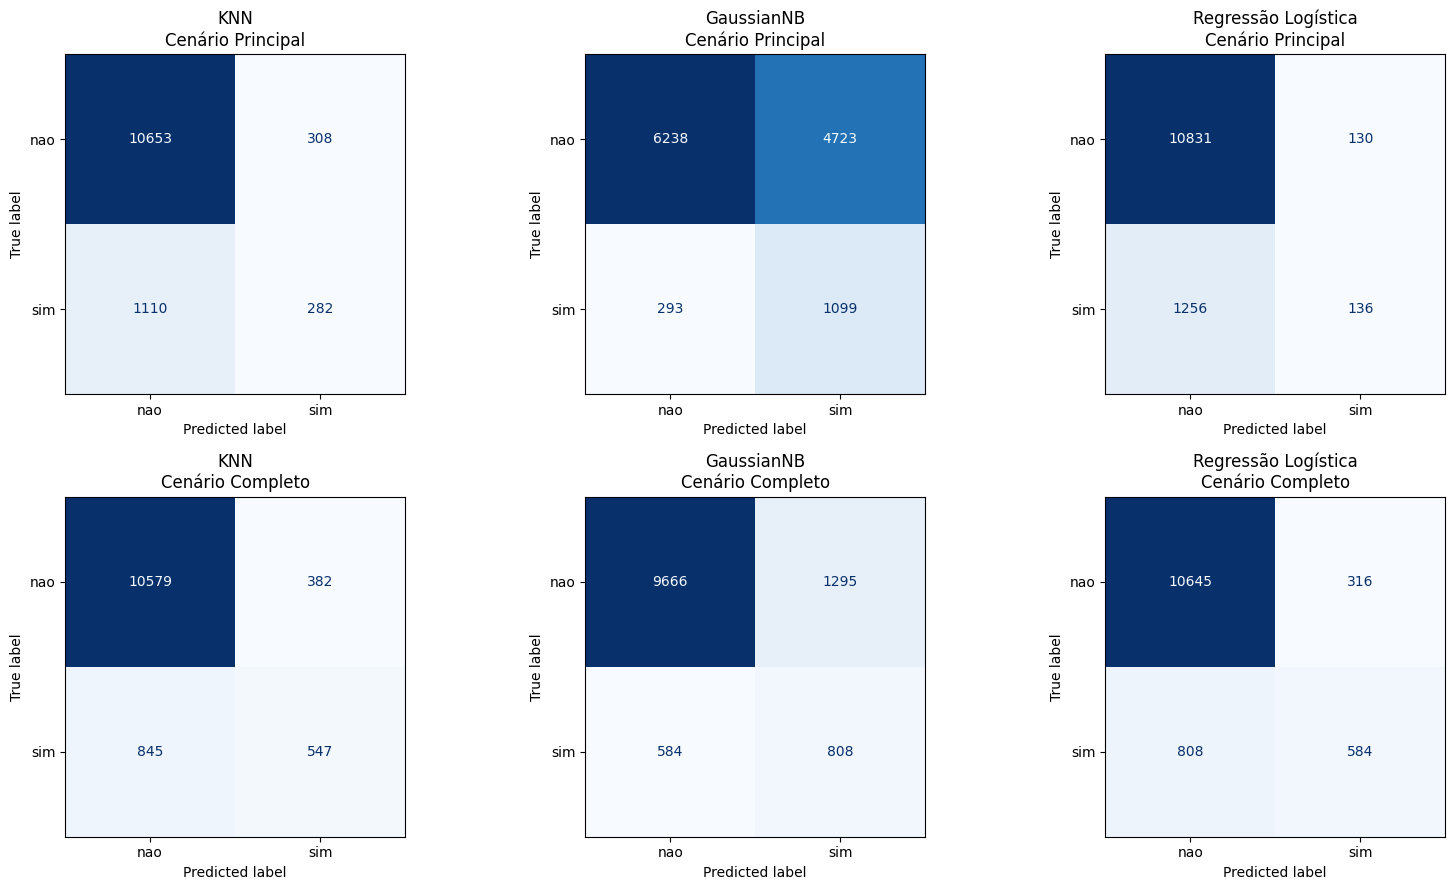

In [109]:
# Visualização das matrizes de confusão
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9)
)

for ax, ((cenario, nome_modelo), matriz) in zip(
    axes.flatten(),
    matrizes_confusao.items()
):
    exibicao = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=['nao', 'sim']
    )

    exibicao.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False
    )

    ax.set_title(f'{nome_modelo}\nCenário {cenario}')

plt.tight_layout()
plt.show()

In [110]:
modelos_principais = {
    'KNN': modelo_knn_principal,
    'GaussianNB': modelo_gaussian_principal,
    'Regressão Logística': modelo_logistica_principal
}

In [111]:
resultados_cv = []

for nome_modelo, modelo in modelos_principais.items():
    notas = cross_val_score(
        modelo,
        X_principal_treino,
        y_treino,
        cv=validacao,
        scoring=metricas['f1_sim']
    )

    resultados_cv.append({
        'cenario': 'Principal',
        'modelo': nome_modelo,
        'f1_cv_media': notas.mean(),
        'f1_cv_desvio': notas.std()
    })

tabela_cv = pd.DataFrame(resultados_cv)
print(tabela_cv)

     cenario               modelo  f1_cv_media  f1_cv_desvio
0  Principal                  KNN     0.285147      0.008343
1  Principal           GaussianNB     0.298877      0.010504
2  Principal  Regressão Logística     0.170577      0.023315


In [112]:
tabela_comparativa = tabela_teste.merge(
    tabela_cv,
    on=['cenario', 'modelo'],
    how='left'
)

tabela_comparativa = tabela_comparativa[
    [
        'cenario',
        'modelo',
        'acuracia',
        'precisao_nao',
        'recall_nao',
        'f1_nao',
        'precisao_sim',
        'recall_sim',
        'f1_sim',
        'falsos_positivos',
        'falsos_negativos',
        'verdadeiros_positivos',
        'verdadeiros_negativos',
        'f1_cv_media',
        'f1_cv_desvio'
    ]
]

tabela_comparativa.round(4)

,cenario,modelo,acuracia,precisao_nao,recall_nao,f1_nao,precisao_sim,recall_sim,f1_sim,falsos_positivos,falsos_negativos,verdadeiros_positivos,verdadeiros_negativos,f1_cv_media,f1_cv_desvio
0,Principal,KNN,0.8852,0.9056,0.9719,0.9376,0.4780,0.2026,0.2846,308,1110,282,10653,0.2851,0.0083
1,Principal,GaussianNB,0.5939,0.9551,0.5691,0.7132,0.1888,0.7895,0.3047,4723,293,1099,6238,0.2989,0.0105
2,Principal,Regressão Logística,0.8878,0.8961,0.9881,0.9399,0.5113,0.0977,0.1641,130,1256,136,10831,0.1706,0.0233
3,Completo,KNN,0.9007,0.9260,0.9651,0.9452,0.5888,0.3930,0.4713,382,845,547,10579,NaN,NaN
4,Completo,GaussianNB,0.8479,0.9430,0.8819,0.9114,0.3842,0.5805,0.4624,1295,584,808,9666,NaN,NaN
5,Completo,Regressão Logística,0.9090,0.9295,0.9712,0.9499,0.6489,0.4195,0.5096,316,808,584,10645,NaN,NaN


Considerando o F1 da classe sim como métrica principal, o GaussianNB apresentou o melhor desempenho no cenário principal, com F1 de 0,3047 e recall de 0,7895. O modelo identificou 1.099 dos 1.392 clientes aderentes, deixando de identificar 293. Entretanto, sua precisão de 0,1888 resultou em 4.723 falsos positivos, indicando um elevado número de contatos sem conversão. Esse comportamento é compatível com a prioridade de reduzir falsos negativos, mas exige maior capacidade operacional do banco.  
O resultado de teste do GaussianNB ficou próximo da média da validação cruzada, de 0,2989, com desvio-padrão de 0,0105, indicando estabilidade entre as partições. No cenário completo, os três modelos apresentaram aumento do F1 da classe positiva. A regressão logística alcançou o maior F1, com 0,5096. Contudo, essa melhora não torna o cenário completo mais adequado para uso prático, pois ele utiliza informações que não estariam disponíveis no momento definido para a seleção dos clientes. Por isso, o GaussianNB no cenário principal é o modelo mais coerente com o critério adotado.